# Day 1 — Seeing the Climate Through Data
## *PART I: From raw numbers to global and local patterns and trends*

### Setup

In [ ]:
import os
if not os.path.exists("workshop_utils"):
    !git clone "https://github.com/Cas-Dec/USLS-Workshop.git"
    %cd workshop
    !pip install -q .

from google.colab import drive
drive.mount('/content/drive')

from workshop_utils.config import init_dirs
init_dirs()

### 1) What is “climate data”?

Before we analyze anything, we need to understand what we are actually working with. In this workshop, we use real observational climate datasets that are collected, cleaned, and published by scientific research groups. Today **we start with two widely used global temperature datasets:**

1) *Berkeley Earth Surface Temperature (BEST)*
- A globally gridded dataset of land and ocean temperature records, compiled from thousands of weather stations and ocean measurements.
- 👉 Provided by Berkeley Earth (USA)
- 👉 https://berkeleyearth.org/data/

2) *NASA GISTEMP*
- A global temperature anomaly dataset maintained by NASA’s Goddard Institute for Space Studies, used widely in climate research and reporting.
- 👉 Provided by NASA GISS
- 👉 https://data.giss.nasa.gov/gistemp/

These datasets are based on real measurements (thermometers, ocean buoys, satellites), processed to remove biases and gaps, and updated over decades of scientific work. We've already downloaded these data and performed the necessary processing for these exercises. If you're interested, you can find out how in *day1_bts.ipynb* under *behind-the-scenes/*.

Let's inspect the data:

In [ ]:
# ... code here

"""
import pandas as pd

best = pd.read_csv("data/processed/best_global_yearly.csv")
gistemp = pd.read_csv("data/processed/gistemp_global_yearly.csv")

best.head()
"""

-> What do you think these numbers represent?

### 2) Global temperature trend
### *The hockey-stick curve*

In [ ]:
# ... code here

"""
import matplotlib.pyplot as plt

plt.figure()
plt.plot(best["Year"], best.iloc[:,1])
plt.title("Global Temperature (Berkeley Earth)")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly")
plt.show()
"""

-> What patterns do you notice?

In [ ]:
# GISTEMP-overlay
# ... code here

plt.figure()

plt.plot(best["Year"], best.iloc[:,1], label="BEST")
plt.plot(gistemp["Year"], gistemp["temp_anomaly"], label="GISTEMP")

plt.legend()
plt.title("Global Temperature Comparison")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly")
plt.show()

### 3) Bacolod climate
### *Let's zoom into Bacolod*

In [ ]:
# ... code here

"""
local = pd.read_csv("data/processed/bacolod_temp_yearly.csv")
local.head()

plt.figure()
plt.plot(local["year"], local["temp_mean"])
plt.title("Bacolod Temperature Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()
"""

-> Do you observe similarities between the temperature evolution globally and in Bacolod? What about differences?

### 4) Compare

In [ ]:
# ... code here

"""
plt.figure()

plt.plot(best["Year"], best.iloc[:,1], label="Global")
plt.plot(local["year"], local["temp_mean"], label="Bacolod")

plt.legend()
plt.title("Global vs Local Temperature Trends")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly")
plt.show()
"""

### (OPTIONAL) Smooth the local data 

In [ ]:
# ... code here

"""
def moving_average(x, w=10):
    return x.rolling(w).mean()

best_smoothed = best.copy()
best_smoothed.iloc[:,1] = moving_average(best.iloc[:,1])

plt.figure()
plt.plot(best["Year"], best.iloc[:,1], alpha=0.3, label="raw")
plt.plot(best_smoothed["Year"], best_smoothed.iloc[:,1], label="smoothed")
plt.legend()
plt.show()
"""

# -> why might smoothing help us understand this data better?

## *PART II: Temperature on Earth is changing. What is driving these changes?*


### 1) Has the sun become dramatically brighter?
*The sun's brightness has an 11-year cycle. In the past, we know that historical grand solar minima (periods of low sunspot activity) have contributed to cooling events like the Little Ice Age.*  

### 2) Have volcanoes changed Earth's temperature?
*Large eruptions inject particles into the atmosphere that reflect sunlight and temporarily cool Earth.*

### 3) Is it ENSO's fault?
*Interactions between the atmosphere and oceans redistribute heat globally. The most famous one is the El Niño-Southern Oscillation (ENSO), which has a great influence on the Philippines too. We know that warmer and colder years can be linked to ENSO variability.*

### 4) Is planet Earth moving closer to our sun?

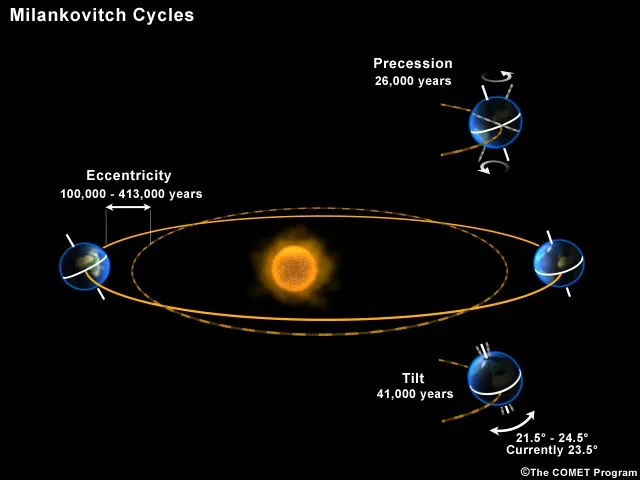

### 5) What about CO2?

[Short explanation on anthropogenic emissions, history since industrial revolution, greenhouse gas effect]

In [ ]:
# ... visualize Mauna Loa Keeling Curve
# ... overlay with global T record

### *"But CO2 fluctuates naturally, it's not actually human's fault!"*

In [ ]:
# ... plot EPICA Dome C Ice Core combined with Mauna Loa.
# -> shows atm. CO2 for past 800 ky
# -> dayum

### So, which driver we examined most closely matches the observed warming trend?

Then, first lesson on data science pitfalls:
-> scatterplot of CO2-T
-> What would you conclude?
-> BUT: correlation versus causation
-> Perhaps funny analogy also visualize?

## *"Temperature is rising. So what? It's just a couple of degrees, and I don't care about polar bears either way. They're mean and eat cute seals."*

-> Then highlight some consequences for the Philippines specifically:

- Sea level
- Heat = energy = typhoons
- Heat = evaporation = extreme precipitation = floods

-> Visualize!

### El-Niño Southern Oscillation (ENSO)

## *PART III: Climate in Negros and the Philippines*

### 1) What is "climate"?

According to Wikipedia: *"Climate is the long-term weather pattern in a region, typically averaged over 30 years."*

The current 'climate' is often defined over the past 30 years. Let's look at the average weather in the Philippines from 1991-2020!

In [ ]:
# ... code here
# visualize, over the PH:
# 1) mean temperature (ERA5, 2D <- RAW / ERA5 / 2m_temperature directory)
# 2) yearly precip (ERA5, 2D<- RAW / ERA5 / precipitation directory)

# -> Ask questions: which regions are warmest (coolest), which regions are wettest (dryest)?

### 2) What climate do we have in Bacolod, Negros? 

Let's look at the monthly cycles of temperature and precipitation!

In [ ]:
# ... code here
# prepare monthly mean T & sum P over 1991-2020 for students
# here they visualize

To divide regions into different climates, the most widely used scheme is the Köppen-Geiger climate classification.

Wikipedia: *"It was first published by German-Russian climatologist Wladimir Köppen (1846–1940) in 1884 [...] Later, German climatologist Rudolf Geiger (1894–1981) introduced some changes to the classification system in 1954 and 1961, which is thus sometimes called the Köppen–Geiger climate classification."*

Köppen made this scheme based on his viewpoint as a botanist, and so the resulting climate groups are strongly associated with plant life, and by extension ecosystems, perfect for applications in biology! Wikipedia: *"The Philippines has five types of climates: tropical rainforest, tropical monsoon, tropical savanna, humid subtropical and oceanic"*

In [ ]:
# let them do KG classification for Bacolod with a decision tree
# -> so here we introduce if-structures, tomorrow we can introduce functions!

### 3) What climate zones exist in the Philippines, and will they change?

To finish, use data (or just visuals) from:

Beck, H. E., McVicar, T. R., Vergopolan, N., Berg, A., Lutsko, N. J., Dufour, A., ... & Miralles, D. G. (2023). High-resolution (1 km) Köppen-Geiger maps for 1901–2099 based on constrained CMIP6 projections. Scientific data, 10(1), 724.

Simply visual, we see the current KG classification across the country, as well as future projections under a changing climate. 